In [162]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [163]:
import seaborn as sns

In [164]:
df = sns.load_dataset('titanic')

In [165]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [166]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [167]:
## Delete the rows or data points to handle missing values

df.shape

(891, 15)

In [168]:
df.dropna().shape

(182, 15)

In [169]:
## Column wise deletion

df.dropna(axis=1)

,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alive,alone
0,0,3,male,1,0,7.2500,Third,man,True,no,False
1,1,1,female,1,0,71.2833,First,woman,False,yes,False
2,1,3,female,0,0,7.9250,Third,woman,False,yes,True
3,1,1,female,1,0,53.1000,First,woman,False,yes,False
4,0,3,male,0,0,8.0500,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,0,0,13.0000,Second,man,True,no,True
887,1,1,female,0,0,30.0000,First,woman,False,yes,True
888,0,3,female,1,2,23.4500,Third,woman,False,no,False
889,1,1,male,0,0,30.0000,First,man,True,yes,True


## Imputation Missing Values

1- Mean Value Imputation

<Axes: xlabel='age', ylabel='Count'>

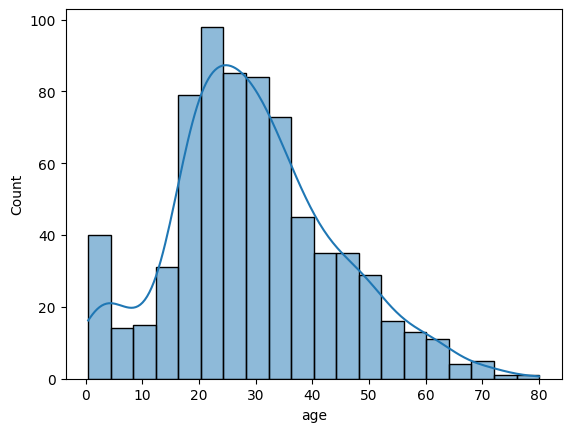

In [170]:
sns.histplot(df['age'], kde=True)

In [171]:
df['Age_Mean'] = df['age'].fillna(df['age'].mean())

In [172]:
df[['age' , 'Age_Mean']]

,age,Age_Mean
0,22.0,22.000000
1,38.0,38.000000
2,26.0,26.000000
3,35.0,35.000000
4,35.0,35.000000
...,...,...
886,27.0,27.000000
887,19.0,19.000000
888,NaN,29.699118
889,26.0,26.000000


In [173]:
## Mean Imputation works well when we have normally distributed data

## Median Value Imputation - If we have outliers in the dataset

In [174]:
df['Age_median'] = df['age'].fillna(df['age'].median())

In [175]:
df[['Age_Mean','Age_median' , 'age']]

,Age_Mean,Age_median,age
0,22.000000,22.0,22.0
1,38.000000,38.0,38.0
2,26.000000,26.0,26.0
3,35.000000,35.0,35.0
4,35.000000,35.0,35.0
...,...,...,...
886,27.000000,27.0,27.0
887,19.000000,19.0,19.0
888,29.699118,28.0,NaN
889,26.000000,26.0,26.0


## Mode Imputation Technique - Categorical Values

In [176]:
df[df['embarked'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Age_Mean,Age_median
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0


In [177]:
mode_value = df[df['embarked'].notna()]['embarked'].mode()[0]
print(mode_value)

S


In [178]:
df['embarked_mode'] = df['embarked'].fillna(mode_value)

In [179]:
df[['embarked_mode' , 'embarked']]

,embarked_mode,embarked
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
...,...,...
886,S,S
887,S,S
888,S,S
889,C,C


# Handling Imbalanced Dataset

1. Up sampling
2. Down Sampling

In [180]:
import numpy as np
import pandas as pd

np.random.seed(123)

n_samples = 1000
class_0_ratio = 0.9
n_class_0 = int(n_samples * class_0_ratio)
n_class_1 = n_samples - n_class_0

In [181]:
n_class_0 , n_class_1

(900, 100)

In [182]:
class_0 = pd.DataFrame({
    'feature_1': np.random.normal(loc=0 ,scale=1 , size=n_class_0),
    'feature_2': np.random.normal(loc=0 ,scale= 1 ,size=n_class_0),
    'target': 0
})

class_1 = pd.DataFrame({
    'feature_1': np.random.normal(loc=1 ,scale=1 , size=n_class_1),
    'feature_2': np.random.normal(loc=1 ,scale= 1 ,size=n_class_1),
    'target' : 1
})

In [183]:
df = pd.concat([class_0 , class_1]).reset_index(drop=True)

In [184]:
df.head()

,feature_1,feature_2,target
0,-1.085631,0.551302,0
1,0.997345,0.419589,0
2,0.282978,1.815652,0
3,-1.506295,-0.252750,0
4,-0.578600,-0.292004,0


In [185]:
df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [186]:
## Upsampling - creating artificial points

df_minority = df[df['target'] == 1]
df_majority = df[df['target'] == 0]

In [187]:
df_minority

,feature_1,feature_2,target
900,0.699768,1.139033,1
901,0.367739,1.025577,1
902,0.795683,0.803557,1
903,1.213696,2.312255,1
904,2.033878,2.187417,1
...,...,...,...
995,0.376371,1.845701,1
996,1.239810,-0.119923,1
997,0.131760,0.640703,1
998,1.902006,-0.609695,1


In [188]:
from sklearn.utils import resample

In [189]:
df_minority_updated = resample(df_minority,replace=True,
         n_samples=len(df_majority),
         random_state=42) #Sample with replacement  

In [190]:
print(df_minority_updated['target'].value_counts())
print(df_majority['target'].value_counts())

target
1    900
Name: count, dtype: int64
target
0    900
Name: count, dtype: int64


In [191]:
df_upsampled = pd.concat([df_minority_updated , df_majority])

In [192]:
df_upsampled['target'].value_counts()

target
1    900
0    900
Name: count, dtype: int64

In [193]:
## DownSampling -Same as Upsampling

df_majority_updated = resample(df_majority,replace=False,
         n_samples=100,
         random_state=42) 

df_majority_updated.shape

(100, 3)

In [194]:
## Now same as before pd.concat and all

## SMOTE(SYNTHETIC MINORITY OVERSAMPLING TECHNIQUE)

1. Core Definition
SMOTE is a statistical technique used in machine learning to address imbalanced datasets. It works by artificially generating new, synthetic data points for the minority class to balance the class distribution, rather than simply duplicating existing data.

2. The Problem it Solves
In highly imbalanced datasets (e.g., 99% legitimate transactions, 1% fraud), machine learning models tend to predict the majority class for everything to achieve high accuracy. They fail to learn the patterns of the minority class. SMOTE fixes this by providing the model with more examples of the minority class to learn from.

In [195]:
from sklearn.datasets import make_classification

In [196]:
X , y = make_classification(n_samples=1000 ,n_redundant=0 , n_features=2 , n_clusters_per_class=1,weights=[0.9],random_state=12)

In [197]:
X

array([[-0.76289759, -0.70680807],
       [-1.07543571, -1.0511621 ],
       [-0.61011459, -0.90980157],
       ...,
       [-1.32643852, -1.815178  ],
       [-0.83348573, -0.5146474 ],
       [-0.30287558, -0.57597532]], shape=(1000, 2))

In [198]:
import pandas as pd

df1 = pd.DataFrame(X, columns=['f1','f2'])
df2 = pd.DataFrame(y, columns=['target'])
final_df = pd.concat([df1 , df2], axis=1)

In [199]:
final_df

,f1,f2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0
...,...,...,...
995,-0.712495,-0.880452,0
996,-2.625830,-2.827891,0
997,-1.326439,-1.815178,0
998,-0.833486,-0.514647,0


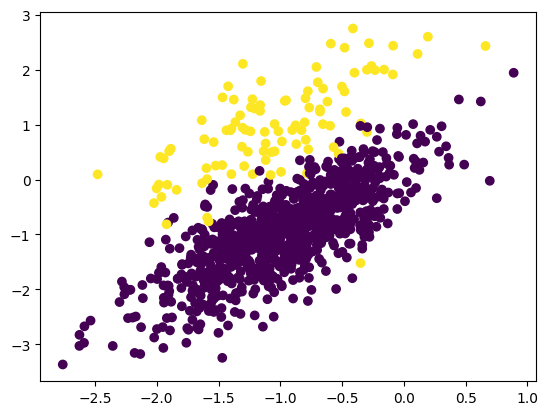

In [200]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'] , final_df['f2'] ,c=final_df['target'] )

In [201]:
%pip install imblearn

Note: you may need to restart the kernel to use updated packages.


In [202]:
from imblearn.over_sampling import SMOTE

In [203]:
## tranform the dataset
oversample = SMOTE()
X , y = oversample.fit_resample(final_df[['f1' , 'f2']] , final_df['target'])

In [204]:
X.shape

(1800, 2)

In [205]:
y.shape

(1800,)

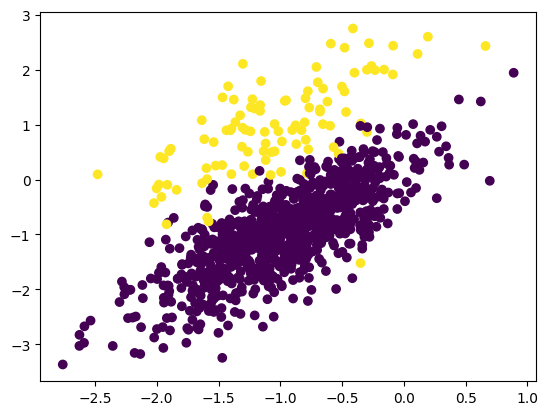

In [206]:
plt.scatter(final_df['f1'] , final_df['f2'] ,c=final_df['target'] )

In [207]:
df1=pd.DataFrame(X , columns=["f1","f2"])
df2=pd.DataFrame(y , columns=["target"])
oversample_df = pd.concat([df1,df2],axis=1)

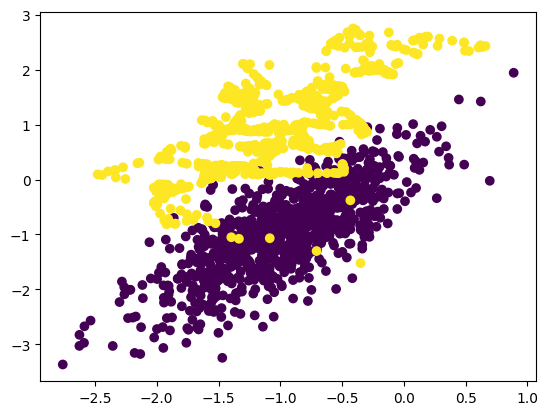

In [208]:
plt.scatter(oversample_df['f1'] , oversample_df['f2'] ,c=oversample_df['target'] )

## 5 number Summary and Box Plot

In [209]:
import numpy as np

In [210]:
lst_marks=[12,45,13,75,12,3,25,79,14,70,24,69,22,99]
minimum , Q1 , median , Q3 , maximum = np.quantile(lst_marks , [0,0.25,0.5,0.75,1])

In [211]:
minimum , Q1 , median , Q3 , maximum

(np.float64(3.0),
 np.float64(13.25),
 np.float64(24.5),
 np.float64(69.75),
 np.float64(99.0))

In [212]:
IQR = Q3 - Q1
print(IQR)

56.5


In [213]:
lower_fence = Q1 - 1.5*(IQR)
higher_fence = Q3 + 1.5*(IQR)

In [214]:
lower_fence , higher_fence

(np.float64(-71.5), np.float64(154.5))

In [215]:
lst_marks=[12,45,13,75,12,3,25,79,14,70,24,69,22,99]

In [216]:
import seaborn as sns

<Axes: >

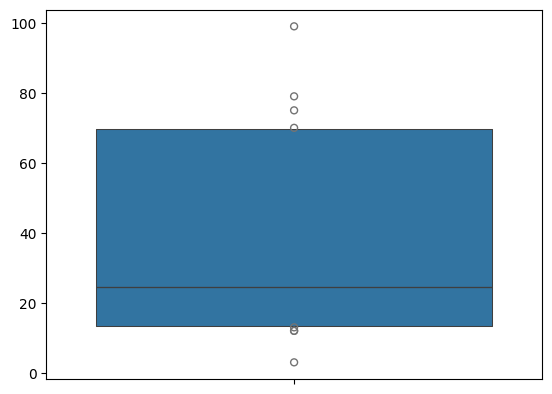

In [217]:
sns.boxenplot(lst_marks)

## One Hot Encoding

In [218]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

In [262]:
## Create a simple dataframe

df = pd.DataFrame({
    "color": ['red' , 'blue' , 'green' , 'red' , 'blue']
})
df

,color
0,red
1,blue
2,green
3,red
4,blue


In [231]:
## Create an instance of onehotencoder
encoder = OneHotEncoder()

In [234]:
## perform fit and transform
encoder1 = encoder.fit_transform(df[['color']]).toarray()

In [236]:
df = pd.DataFrame(data=encoder1 , columns=["blue" , 'green' , 'red'])
df

,blue,green,red
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,0.0,1.0
4,1.0,0.0,0.0


## Label Encodding

In [237]:
from sklearn.preprocessing import LabelEncoder
lbl_encoder = LabelEncoder()

In [241]:
lbl_encoder.fit_transform(df[['color']])

c:\Users\biswa\Anaconda3PythonLatest2025\envs\venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([2, 0, 1, 2, 0])

In [242]:
lbl_encoder.transform([['blue']])

c:\Users\biswa\Anaconda3PythonLatest2025\envs\venv\Lib\site-packages\sklearn\preprocessing\_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([0])

In [243]:
lbl_encoder.transform([['red']])

c:\Users\biswa\Anaconda3PythonLatest2025\envs\venv\Lib\site-packages\sklearn\preprocessing\_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([2])

## Ordinal Encoding

Definition
Ordinal encoding is a data preprocessing technique used to convert categorical data into numerical integers, specifically when the categories have a natural, inherent order or rank (ordinal data).

In [257]:
from sklearn.preprocessing import OrdinalEncoder

rankings = ['Name' , 'level' , 'stress']

data = np.array([
                ['Orin',2,'Low'],
                ['Horin',5,'High'],
                ['Kira',3.5,'Medium']
                ])

df = pd.DataFrame(data=data , columns=rankings)
df

,Name,level,stress
0,Orin,2,Low
1,Horin,5,High
2,Kira,3.5,Medium


In [260]:
encoder = OrdinalEncoder(categories=[['Low' , 'Medium' ,'High']])
df['Encoded_stress'] = encoder.fit_transform(df[['stress']])
print(df)

    Name level  stress  Encoded_stress
0   Orin     2     Low             0.0
1  Horin     5    High             2.0
2   Kira   3.5  Medium             1.0


In [263]:
encoder = OrdinalEncoder()
encoder.fit_transform(df[['color']])

array([[2.],
       [0.],
       [1.],
       [2.],
       [0.]])